In [9]:

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
event_labels = {'boogaloo': 'political',
 'boulderfire': 'disaster',
 'buffaloshooting': 'violence',
 'coupdc': 'political',
 'elpaso': 'violence',
 'floodtx': 'disaster',
 'hawaiifires': 'disaster',
 'helene': 'disaster',
 'lewiston': 'violence',
 'montereypark': 'violence',
 'socalfires': 'disaster',
 'uvalde': 'violence',
 'virginiabeach': 'violence',
 'vehiclela': 'violence'}

In [12]:
events_org = {
    'violence': ['boulderfire', 'buffaloshooting', 'elpaso',
                 'montereypark', 'uvalde', 'virginiabeach', 'vehiclela'],
    'disaster': ['floodtx', 'hawaiifires', 'helene', 'socalfires']
}


In [13]:
violence_dfs = []
disaster_dfs = []

In [176]:
data_id = "hits=2"
datasets_dir = Path(f"output/{data_id}/")

datasets = [d.name for d in datasets_dir.iterdir() if d.is_dir()]

data = []  # Store dataset results from temporal analysis
xlim = (-7,30)  # Define plot limits

# remove if present (avoid ValueError if missing)
for rm in ["lewiston"]:
    if rm in datasets:
        datasets.remove(rm)

# Collect frames in lists, then concat once at end (fast + correct)
v_neg7, v_onset, v_pos4, v_pos5, v_pos10, v_pos11, v_pos12, v_pos20, v_pos30 = [], [], [], [], [], [], [], [] , []
d_neg7, d_onset, d_pos4, d_pos5, d_pos10, d_pos11, d_pos12,d_pos20, d_pos30 = [], [], [], [], [], [], [], [], []

for dataset in datasets:
    data_dir = datasets_dir / dataset
    words_counts_dir = data_dir / "words_counts" / "event"

    # Load daily files
    neg7  = pd.read_csv(words_counts_dir / "day_-7.csv")
    onset = pd.read_csv(words_counts_dir / "day_0.csv")
    pos4  = pd.read_csv(words_counts_dir / "day_4.csv")
    pos5  = pd.read_csv(words_counts_dir / "day_5.csv")
    pos10 = pd.read_csv(words_counts_dir / "day_10.csv")
    pos11 = pd.read_csv(words_counts_dir / "day_11.csv")
    pos12 = pd.read_csv(words_counts_dir / "day_12.csv")
    pos20 = pd.read_csv(words_counts_dir / "day_20.csv")
    pos30 = pd.read_csv(words_counts_dir / "day_30.csv")
    # Add identifiers (helps later)
    for df_, day in [(neg7, -7), (onset, 0), (pos4, 4), (pos5, 5), (pos10, 10),(pos10, 11),(pos10, 12),(pos20, 20),(pos30, 30)]:
        df_["dataset"] = dataset
        df_["day"] = day

    # Assign to violence vs disaster
    if dataset in events_org["violence"]:
        v_neg7.append(neg7)
        v_onset.append(onset)
        v_pos4.append(pos4)
        v_pos5.append(pos5)
        v_pos10.append(pos10)
        v_pos11.append(pos11)
        v_pos12.append(pos12)
        v_pos20.append(pos20)
        v_pos30.append(pos30)

    elif dataset in events_org["disaster"]:
        d_neg7.append(neg7)
        d_onset.append(onset)
        d_pos4.append(pos4)
        d_pos5.append(pos5)
        d_pos10.append(pos10)
        d_pos11.append(pos11)
        d_pos12.append(pos12)
        d_pos20.append(pos20)
        d_pos30.append(pos30)

    else:
        # dataset not categorized; skip or handle as you like
        print(f"Skipping (not in events_org): {dataset}")

# Final combined DataFrames
v_tot_neg7  = pd.concat(v_neg7,  ignore_index=True) if v_neg7 else pd.DataFrame()
v_tot_onset = pd.concat(v_onset, ignore_index=True) if v_onset else pd.DataFrame()
v_tot_pos4  = pd.concat(v_pos4,  ignore_index=True) if v_pos4 else pd.DataFrame()
v_tot_pos5  = pd.concat(v_pos5,  ignore_index=True) if v_pos5 else pd.DataFrame()
v_tot_pos10 = pd.concat(v_pos10, ignore_index=True) if v_pos10 else pd.DataFrame()
v_tot_pos11 = pd.concat(v_pos11, ignore_index=True) if v_pos11 else pd.DataFrame()
v_tot_pos12 = pd.concat(v_pos12, ignore_index=True) if v_pos12 else pd.DataFrame()
v_tot_pos20 = pd.concat(v_pos20, ignore_index=True) if v_pos20 else pd.DataFrame()
v_tot_pos30 = pd.concat(v_pos10, ignore_index=True) if v_pos30 else pd.DataFrame()

d_tot_neg7  = pd.concat(d_neg7,  ignore_index=True) if d_neg7 else pd.DataFrame()
d_tot_onset = pd.concat(d_onset, ignore_index=True) if d_onset else pd.DataFrame()
d_tot_pos4  = pd.concat(d_pos4,  ignore_index=True) if d_pos4 else pd.DataFrame()
d_tot_pos5  = pd.concat(d_pos5,  ignore_index=True) if d_pos5 else pd.DataFrame()
d_tot_pos10 = pd.concat(d_pos10, ignore_index=True) if d_pos10 else pd.DataFrame()
d_tot_pos11 = pd.concat(d_pos11, ignore_index=True) if d_pos11 else pd.DataFrame()
d_tot_pos12 = pd.concat(d_pos12, ignore_index=True) if d_pos12 else pd.DataFrame()
d_tot_pos20 = pd.concat(d_pos10, ignore_index=True) if d_pos20 else pd.DataFrame()
d_tot_pos30 = pd.concat(d_pos10, ignore_index=True) if d_pos30 else pd.DataFrame()


violence_rows = []
disaster_rows = []

for dataset in datasets:
    data_dir = datasets_dir / dataset
    words_counts_dir = data_dir / "words_counts" / "event"

    day_files = {
        -7: "day_-7.csv",
         0: "day_0.csv",
         4: "day_4.csv",
         5: "day_5.csv",
         10: "day_10.csv",
         11: "day_11.csv",
         12: "day_12.csv",
         20: "day_20.csv",
         30: "day_30.csv",
    }

    for day, fname in day_files.items():
        df = pd.read_csv(words_counts_dir / fname)

        # add metadata
        df["dataset"] = dataset
        df["day"] = day

        if dataset in events_org["violence"]:
            df["group"] = "violence"
            violence_rows.append(df)

        elif dataset in events_org["disaster"]:
            df["group"] = "disaster"
            disaster_rows.append(df)

# Final collapsed DataFrames
violence_df = pd.concat(violence_rows, ignore_index=True)
disaster_df = pd.concat(disaster_rows, ignore_index=True)

Skipping (not in events_org): tornadokentucky
Skipping (not in events_org): milton


FileNotFoundError: [Errno 2] No such file or directory: 'output/hits=2/firekansas/words_counts/event/day_10.csv'

In [48]:
collapse_map_v = {

    # ---------------------------------------------------
    # Political leadership & federal response
    # ---------------------------------------------------
    "president": [
        "president", "u.s. president", "white house",
        "administration", "executive branch",
        "trump", "donald trump",
        "biden", "joe biden"
    ],

    # ---------------------------------------------------
    # Geographic & venue anchors (filtering only)
    # ---------------------------------------------------
    "state": [
        "state", "governor", "state government",
        "city",
        "el paso", "el", "paso",
        "new york", "york", "york city", "new",
        "texas", "tx",
        "uvalde", "uvalde texas",
        "buffalo", "buffaloshooting", "buffalo new york",
        "virginia", "virginia beach",
        "monterey", "monterey park",
        "california",

        "elementary", "elementary school", "uvalde elementary",
        "middle school", "high school",
        "school", "campus",
        "college", "university",

        "church", "synagogue", "mosque", "temple",
        "supermarket", "grocery", "grocery store", "market",
        "nightclub", "club",
        "bar",
        "mall", "shopping center",
        "concert", "festival"
    ],

    # ---------------------------------------------------
    # Policy, law, and regulation discourse
    # ---------------------------------------------------
    "legislation": [
        "legislation", "law", "bill", "act",
        "gun law", "gun control", "firearms regulation",
        "weapons ban", "assault weapons ban",
        "background checks",
        "congress", "senate", "house of representatives",
        "policy", "public policy",
        "executive order"
    ],

    # ---------------------------------------------------
    # Law enforcement & investigation
    # ---------------------------------------------------
    "police": [
        "police", "cops", "law enforcement",
        "officers", "deputies",
        "sheriff", "state troopers",
        "fbi", "atf", "homeland security",
        "authorities", "investigators",
        "swat", "task force",

        "arrest", "arrested", "custody",
        "charge", "charges", "charged"
    ],

    # ---------------------------------------------------
    # Violent event & attack language
    # ---------------------------------------------------
    "shooting": [
        "shooting", "shoot", "shot",
        "mass", "mass shooting", "mass-shooting",
        "active shooter",
        "gunfire",
        "drive by shooting",
        "school shooting", "church shooting",
        "nightclub shooting",
        "attack", "violent attack"
    ],

    # ---------------------------------------------------
    # Weapons & equipment
    # ---------------------------------------------------
    "firearm": [
        "firearm", "gun",
        "handgun", "pistol",
        "rifle", "ar-15", "ar15", "assault rifle",
        "shotgun",
        "weapon",
        "ammunition", "bullets", "magazine"
    ],

    # ---------------------------------------------------
    # Casualties & human impact
    # ---------------------------------------------------
    "victims": [
        "victims",
        "dead", "death", "deaths",
        "fatality", "fatalities",
        "killed", "kill", 
        "injuries", "wounded",
        "casualties",
        "survivors", "people", "old", "year old", "student", "teacher"
    ],

    # ---------------------------------------------------
    # Perpetrator identity
    # ---------------------------------------------------
    "suspect": [
        "suspect",
        "shooter", "gunman",
        "assailant", "attacker",
        "perpetrator",
        "person of interest"
    ],

    # ---------------------------------------------------
    # Ideological violence & radicalization
    # ---------------------------------------------------
    "extremism": [
        "extremism", "violent extremism",
        "radicalization", "radicalized",
        "militant ideology",
        "fanaticism",
        "political extremism",
        "religious extremism",
        "fringe ideology"
    ],

    # ---------------------------------------------------
    # Terror & mass-casualty violence
    # ---------------------------------------------------
    "violence": [
        "terror", "terrorism", "terrorist",
        "domestic terrorism",
        "political violence",
        "ideological violence",
        "mass casualty attack",
        "insurgent violence" , "gun violence", "violence"
    ],

    # ---------------------------------------------------
    # Bias-motivated violence
    # ---------------------------------------------------
    "hate_crime": [
        "hate", "hate crime",
        "bias crime",
        "racially motivated",
        "religiously motivated",
        "identity based attack",
        "targeted attack",
        "ideological hatred", "black", "latinx"
    ],

    # ---------------------------------------------------
    # Racist ideology & identity-based violence
    # ---------------------------------------------------
    "racism": [
        "racism", "racial violence",
        "white supremacy", "supremacist",
        "neo nazi", "nazism",
        "antisemitism", "antisemitic",
        "islamophobia",
        "xenophobia",
        "racial hatred", "white", 
    ]
}


# Build reverse lookup once
variant_to_canonical = {
    v.lower(): canonical
    for canonical, variants in collapse_map_v.items()
    for v in variants
}

def normalize_word(w):
    # Handle NaN / non-strings safely
    if pd.isna(w):
        return w  # keep NaN (or return "" if you prefer)
    w = str(w).lower().strip()
    return variant_to_canonical.get(w, w)

# Apply
violence_df["word_norm"] = violence_df["word"].apply(normalize_word)

In [51]:
top50_violence = (
    violence_df[violence_df["group"] == "violence"]
    .groupby("word_norm", as_index=False)
    .agg({
        "count": "sum",
        "tfidf": "mean"
    })
    .rename(columns={"word_norm": "word"})
    .assign(group="violence")
    .sort_values("count", ascending=False)
    .head(50)
    [["word", "count", "tfidf", "group"]]
)


In [52]:
top50_violence.sort_values("tfidf", ascending=False)

,word,count,tfidf,group
3990,shooting,3508,0.038007,violence
3832,say,795,0.037423,violence
4894,year,497,0.037249,violence
4125,state,7485,0.033123,violence
2807,man,246,0.028566,violence
4589,victims,2431,0.027349,violence
2008,firearm,1317,0.024919,violence
3412,police,783,0.024213,violence
2071,friday,138,0.024032,violence
4594,violence,615,0.023497,violence


In [167]:
collapse_map_d = {


    # ---------------------------------------------------
    # Aid / response
    # ---------------------------------------------------
    "rescue": [
        "rescue", "rescues",
        "search and rescue", "sar",
        "rescue operation", "rescue operations",
        "emergency rescue", "water rescue",
        "air rescue", "swift water rescue",
        "evacuation", "evacuations",
        "evacuated", "evacuating",
        "emergency response", "first responders", "search"
    ],

    "help": [
        "help", "aid", "assistance",
        "relief", "support",
        "emergency help", "emergency assistance",
        "disaster relief", "humanitarian aid",
        "supplies", "donations","recovery",
        "volunteers", "volunteer efforts", "response"
    ],

    "victims": [
        "victims", "survivors",
        "residents", "families",
        "people affected", "those affected",
        "displaced residents", "evacuees", "people"
    ],

    "federal aid": [
        "federal aid", "federal assistance",
        "federal help", "federal response",
        "fema", "disaster declaration",
        "emergency declaration",
        "presidential declaration",
        "national guard",
        "relief funding", "emergency funding", "federal", "official"
    ],

    # ---------------------------------------------------
    # Event specific: natural disasters
    # ---------------------------------------------------
    "natural disaster": ["helene", "milton"
        "natural disaster", "disaster", "catastrophe",

        # storms & cyclones
        "hurricane", "tornado", "storm",
        "tropical storm", "tropical cyclone",
        "cyclone", "typhoon",
        "hurricane helene", "storm helene",
        "tropical storm helene",

        # flooding
        "flood", "flooding", "flash flood", "flash flooding",
        "floodwaters", "high water",
        "storm surge", "surge",
        "rain", "rainfall", "heavy rain",
        "downpour",

        # wind
        "wind", "winds", "high winds",
        "gust", "gusts","flash",

        # fires
        "wildfire", "wildfires",
        "fire", "fires",
        "brush fire", "forest fire",
        "structure fire",

        # notable fire events
        "maui fires", "maui wildfire", "maui wildfires",
        "hawaii fires", "hawaii wildfire", "hawaiifires",
        "socal fires", "so cal fires",
        "southern california fires", "california fires",
        "socalfires"
    ],
    # ---------------------------------------------------
    # Casualties
    # ---------------------------------------------------
    "fatalities": [
        "dead", "death", "deaths",
        "fatality", "fatalities",
        "killed", "loss of life",
        "lives lost",
        "body", "bodies",
        "confirmed dead", "death toll",
        "rising death toll", "kill"
    ],

    # ---------------------------------------------------
    # Infrastructure & property impact
    # ---------------------------------------------------
    "damage": [
        "damage", "damages",
        "destruction", "destroyed",
        "ruined", "leveled",
        "collapsed", "collapse",
        "wrecked", "burned",
        "flooded homes", "flooded streets","home", "homes"

        "power outage", "power outages",
        "outage", "outages",
        "blackout", "blackouts",
        "downed power lines",

        "road closures", "closed roads",
        "bridge collapse", "washed out roads",
        "infrastructure damage",
        "property damage", "impact"
    ],

    # ---------------------------------------------------
    # Severity & scale
    # ---------------------------------------------------
    "devastating": [
        "devastating", "catastrophic",
        "historic", "record breaking",
        "unprecedented", "massive",
        "severe", "extreme",
        "deadly", "destructive",
        "crippling", "widespread",
        "chaotic", "disastrous"
    ],
##policy
    "president": [
        "president", "u.s. president", "white house",
        "administration", "executive branch",
        "trump", "donald trump",
        "biden", "joe biden",
    ],
    "state of emergency": ["state of emergency", "emergency declaration", "declared emergency", "emergency"],
    "evacuation" : ["evacuation", "evacuate", "evacuations", "evacuated"],
    "state":   
        ["tx", "texas","ca", "calif", "california","hi", "hawaii", "hawaiian","fl", "florida","nc", "north carolina","sc", "south carolina","ga", "georgia","tn", "tennessee","va", "virginia","al", "alabama",

        # --- Places / Cities / Regions (high-signal) ---
        # Hawaii / Maui
        "maui",
        "lahaina",
        "maui county",
        "honolulu",

        # Southern California / LA region
        "los angeles", "la", "l.a.", "los angeles county", "los", "angeles",
        "san diego", "san diego county",
        "ventura", "ventura county",
        "orange county", "oc",
        
        # Texas flood common cities/regions
        "houston",
        "austin",
        "san antonio",
        "dallas",
        "hill country", "texas hill country","central texas","island", "county"],
    }



In [168]:
variant_to_canonical_d = {
    v.lower(): canonical
    for canonical, variants in collapse_map_d.items()
    for v in variants
}

def normalize_word_d(w):
    if pd.isna(w):
        return w
    w = str(w).lower().strip()
    return variant_to_canonical_d.get(w, w)

disaster_df["word_norm"] = disaster_df["word"].apply(normalize_word_d)

In [169]:
top50_disaster = (
    disaster_df[disaster_df["group"] == "disaster"]
    .groupby("word_norm", as_index=False)
    .agg({
        "count": "sum",
        "tfidf": "mean"
    })
    .rename(columns={"word_norm": "word"})
    .assign(group="disaster")
    .sort_values("count", ascending=False)
    .head(50)
    [["word", "count", "tfidf", "group"]]
)

In [160]:
top50_disaster.sort_values("tfidf", ascending = False )

,word,count,tfidf,group
1007,department,115,0.034440,disaster
2239,state,3581,0.033000,disaster
1780,natural disaster,3397,0.030381,disaster
1526,july,210,0.028943,disaster
1881,people,554,0.026872,disaster
2130,say,405,0.025401,disaster
2488,week,184,0.022437,disaster
2646,year,211,0.022040,disaster
944,day,186,0.022039,disaster
1472,include,166,0.020524,disaster


In [143]:
top_v_words = ["president","state","legislation","police","shooting","firearm", "victims",
"suspect",
"extremism",
"violence",
"hate_crime","racism"]

In [170]:
top_d_words = ["rescue","help","victims", "federal aid",
               "natural disaster", "fatalities","damage","devastating",
               "state","president","evacuation","state of emergency"
]

In [145]:
target_words = [w.lower().strip() for w in top_v_words]

day_word_avg_v = (
    violence_df[violence_df["word_norm"].isin(target_words)]
    .groupby(["day", "word_norm"], as_index=False)
    .agg(tfidf=("tfidf", "mean"))
)

radar_df_v = (
    day_word_avg_v
    .pivot(index="day", columns="word_norm", values="tfidf")
    .fillna(0.0)
)

# Ensure column order matches top_v_words
radar_df_v = radar_df_v.reindex(columns=target_words, fill_value=0.0)


In [171]:
target_words_d = [w.lower().strip() for w in top_d_words]

day_word_avg_d = (
    disaster_df[disaster_df["word_norm"].isin(target_words_d)]
    .groupby(["day", "word_norm"], as_index=False)
    .agg(tfidf=("tfidf", "mean"))
)

radar_df_d = (
    day_word_avg_d
    .pivot(index="day", columns="word_norm", values="tfidf")
    .fillna(0.0)
)

# Ensure column order matches top_v_words
radar_df_d = radar_df_d.reindex(columns=target_words_d, fill_value=0.0)


In [172]:
def plot_radar_for_day(day, values, labels, normalize=True, label_pad=18):
    vals = values.astype(float).values

    # Normalize per day so radar shows shape
    if normalize and vals.max() > 0:
        vals = vals / vals.max()

    # Close loop
    vals = np.append(vals, vals[0])
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
    angles = np.append(angles, angles[0])

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    ax.plot(angles, vals, linewidth=2)
    ax.fill(angles, vals, alpha=0.25)

    # ---- Move labels outward ----
    ax.set_thetagrids(angles[:-1] * 180 / np.pi, labels)
    ax.tick_params(axis='x', pad=label_pad)

    # ---- Rotate labels to follow circle ----
    for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
        angle_deg = np.degrees(angle)
        label.set_rotation(angle_deg)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("center")

    ax.set_ylim(0, 1.05 if normalize else vals.max() * 1.05)
    ax.set_title(f"Disaster — Day {day} — Avg TF-IDF (normalized)", y=1.12)

    plt.show()


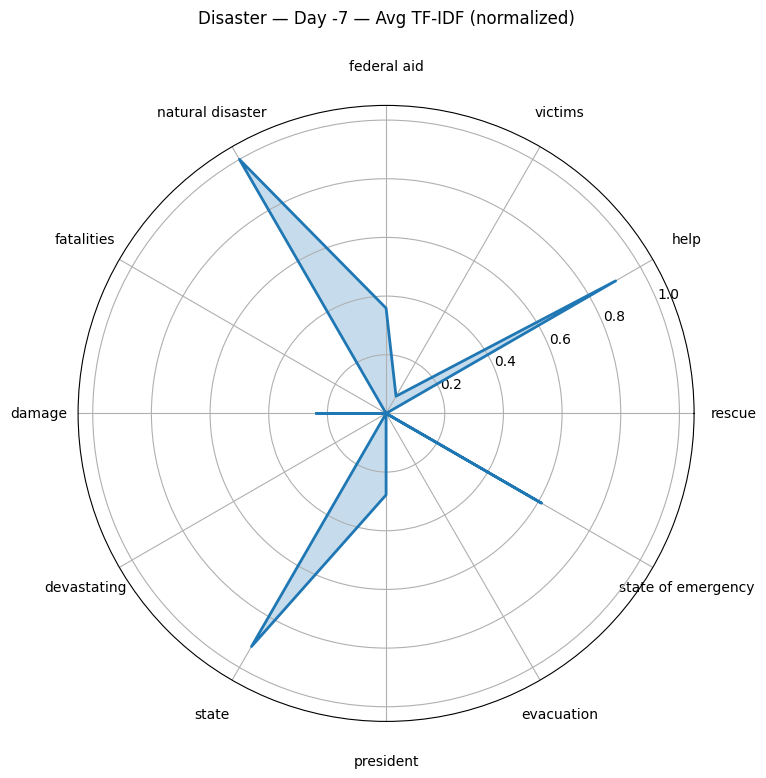

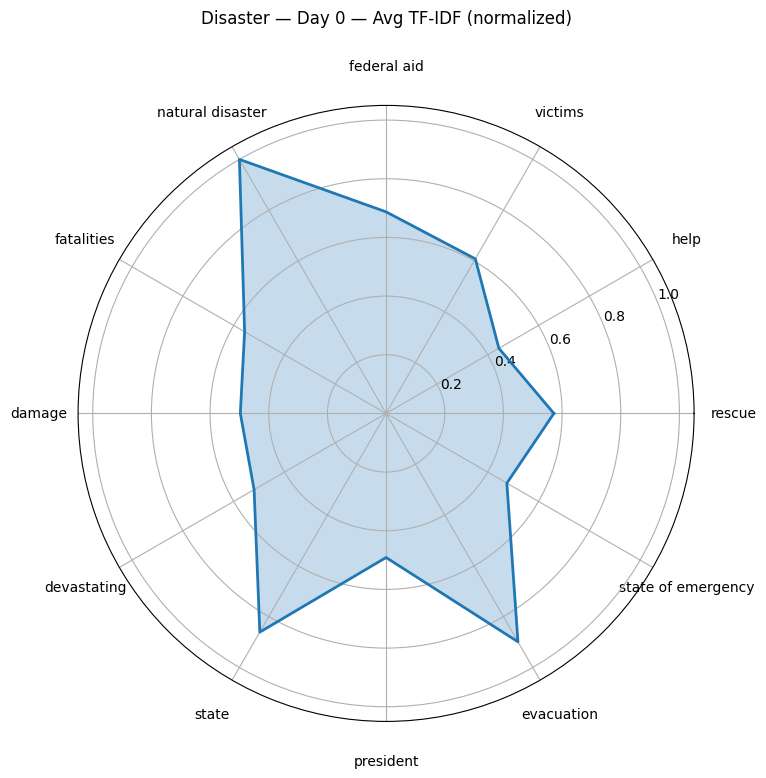

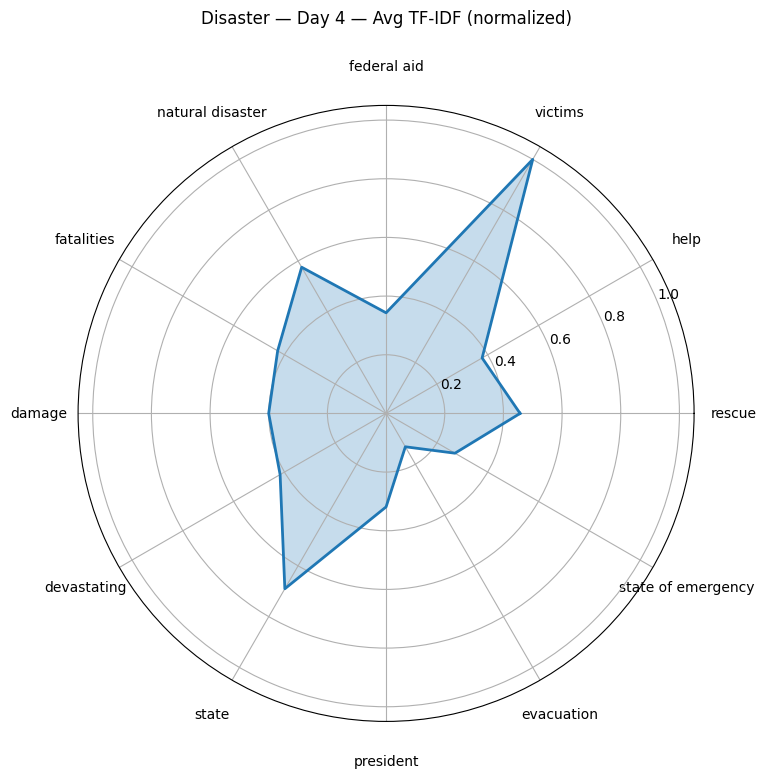

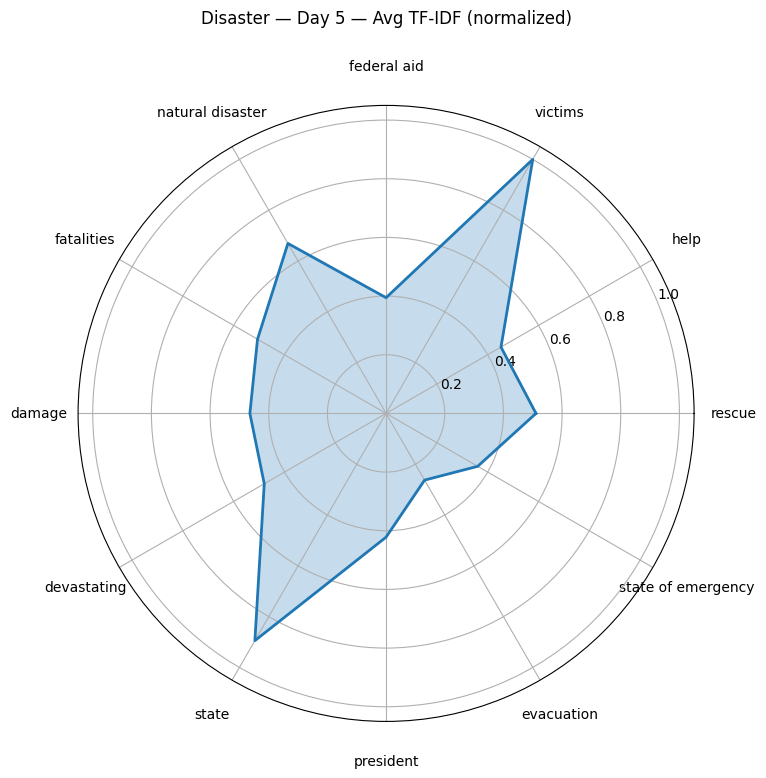

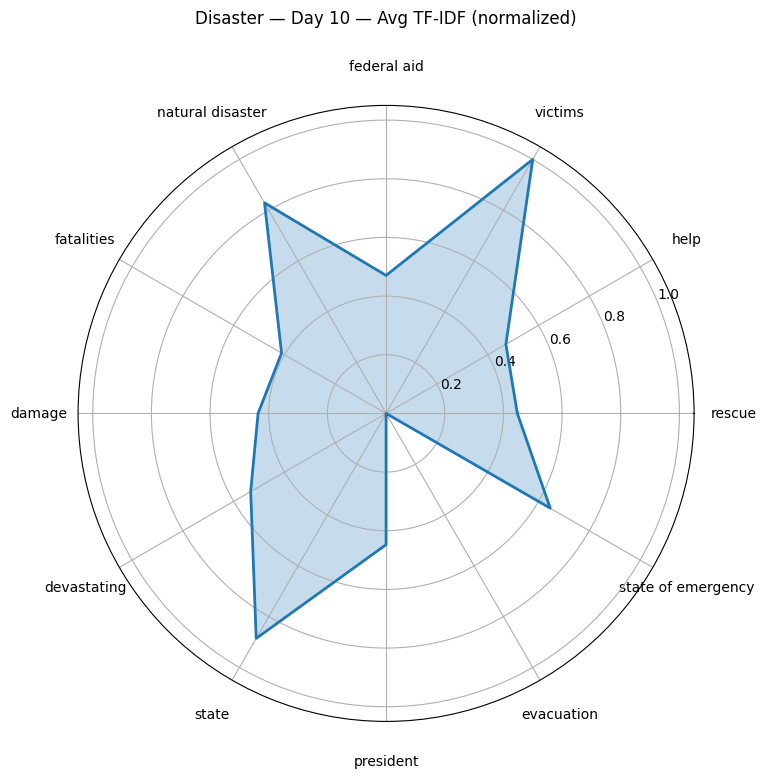

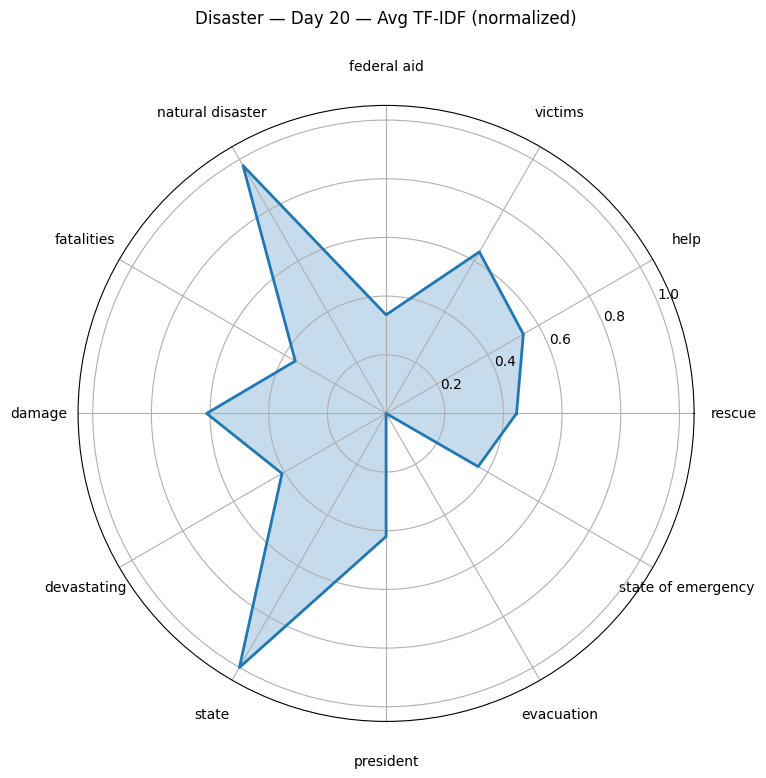

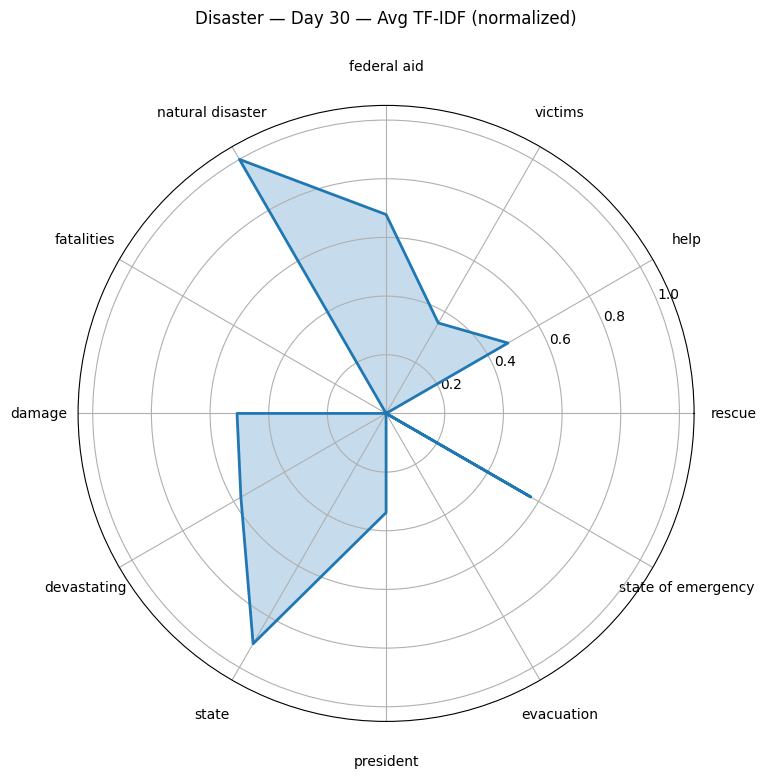

In [173]:
for day in sorted(radar_df_d.index):
    plot_radar_for_day(day, radar_df_d.loc[day], radar_df_d.columns, normalize=True)


In [174]:


def plot_radar_overlay_days(
    radar_df,
    days=None,               # list like [-7, 0, 4, 5, 24]; None = all days
    word_order=None,         # your preferred axis order
    normalize=True,          # normalize each day's vector to max=1
    title="Violence — Avg TF-IDF Radar (Overlay)", label_pad=18
):
    # Pick days
    if days is None:
        days = sorted(radar_df.index.tolist())

    # Reorder axes
    if word_order is None:
        labels = list(radar_df.columns)
    else:
        labels = [w for w in word_order if w in radar_df.columns]

    if len(labels) < 3:
        raise ValueError("Need at least 3 words/axes for a radar plot.")

    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
    angles = np.append(angles, angles[0])

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for day in days:
        if day not in radar_df.index:
            continue

        vals = radar_df.loc[day, labels].astype(float).values

        if normalize and vals.max() > 0:
            vals = vals / vals.max()

        vals = np.append(vals, vals[0])

        ax.plot(angles, vals, linewidth=2, label=f"Day {day}")
        ax.fill(angles, vals, alpha=0.08)

        # ---- Move labels outward ----
    ax.set_thetagrids(angles[:-1] * 180 / np.pi, labels)
    ax.tick_params(axis='x', pad=label_pad)

    # ---- Rotate labels to follow circle ----
    for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
        angle_deg = np.degrees(angle)
        label.set_rotation(angle_deg)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("center")

   
    ax.set_ylim(0, 1.05 if normalize else None)
    ax.set_title(title, y=1.1)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.10))

    plt.show()


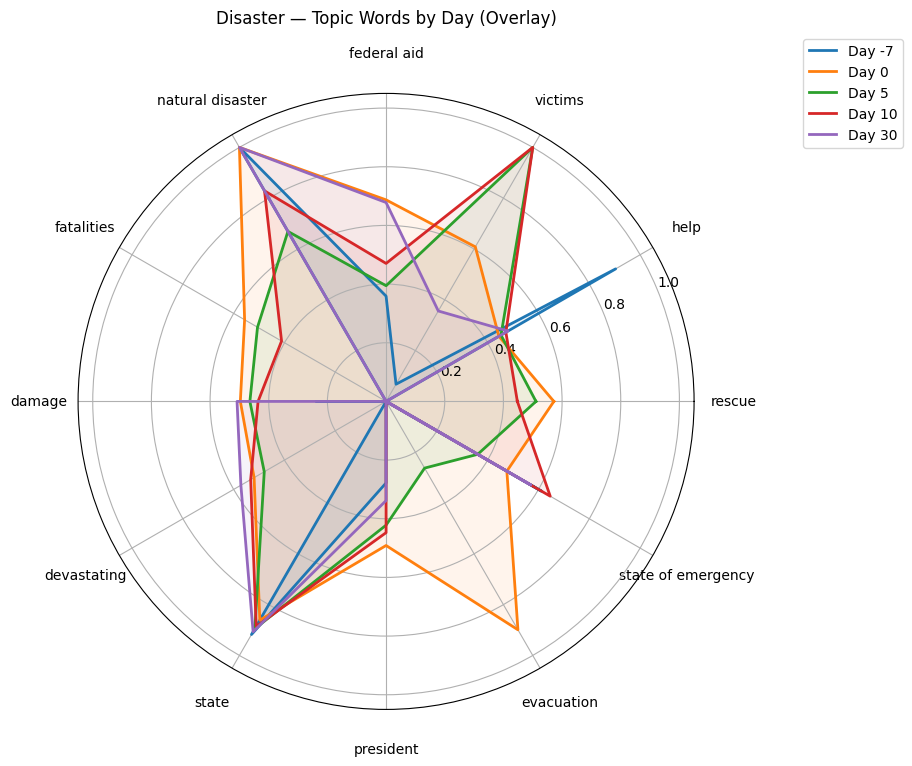

In [175]:
plot_radar_overlay_days(
    radar_df_d,
    days=[-7, 0, 5, 10,30],
    normalize=True,
    title="Disaster — Topic Words by Day (Overlay)"
)